In [1]:
import torch
from config import ExperimentConfig
from dataset import prepare_data, WhaleDataset, build_val_transform
from models import build_model
from final_evaluation import (
    get_classifier_predictions,
    get_retrieval_predictions,
    evaluate_base_metrics,
    sweep_thresholds
)
from visualization import plot_evaluation

In [2]:
from dataset import build_dataloaders, build_metric_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

experiments = {
    "baseline": {
        "config": "experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/config.json",
        "checkpoint": "experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth",
    },
    "arcface": {
        "config": "experiments/20260403_163615_arcface_effnetb5_6c8d152f/config.json",
        "checkpoint": "experiments/20260403_163615_arcface_effnetb5_6c8d152f/checkpoints/best.pth",
    },
    "triplet": {
        "config": "experiments/20260404_143337_triplet_effnetb5_3ae3db53/config.json",
        "checkpoint": "experiments/20260404_143337_triplet_effnetb5_3ae3db53/checkpoints/best.pth",
    },
}


=== baseline ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracting Classifier Preds:   0%|          | 0/24 [00:15<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

Base Metrics: {'known_recall@1': 0.2762312591075897, 'known_recall@5': 0.40899357199668884, 'mean_known_conf': 0.2102949023246765, 'mean_new_whale_conf': 0.2043268382549286}
Optimal Threshold: 0.121 -> MAP@5: 0.3682


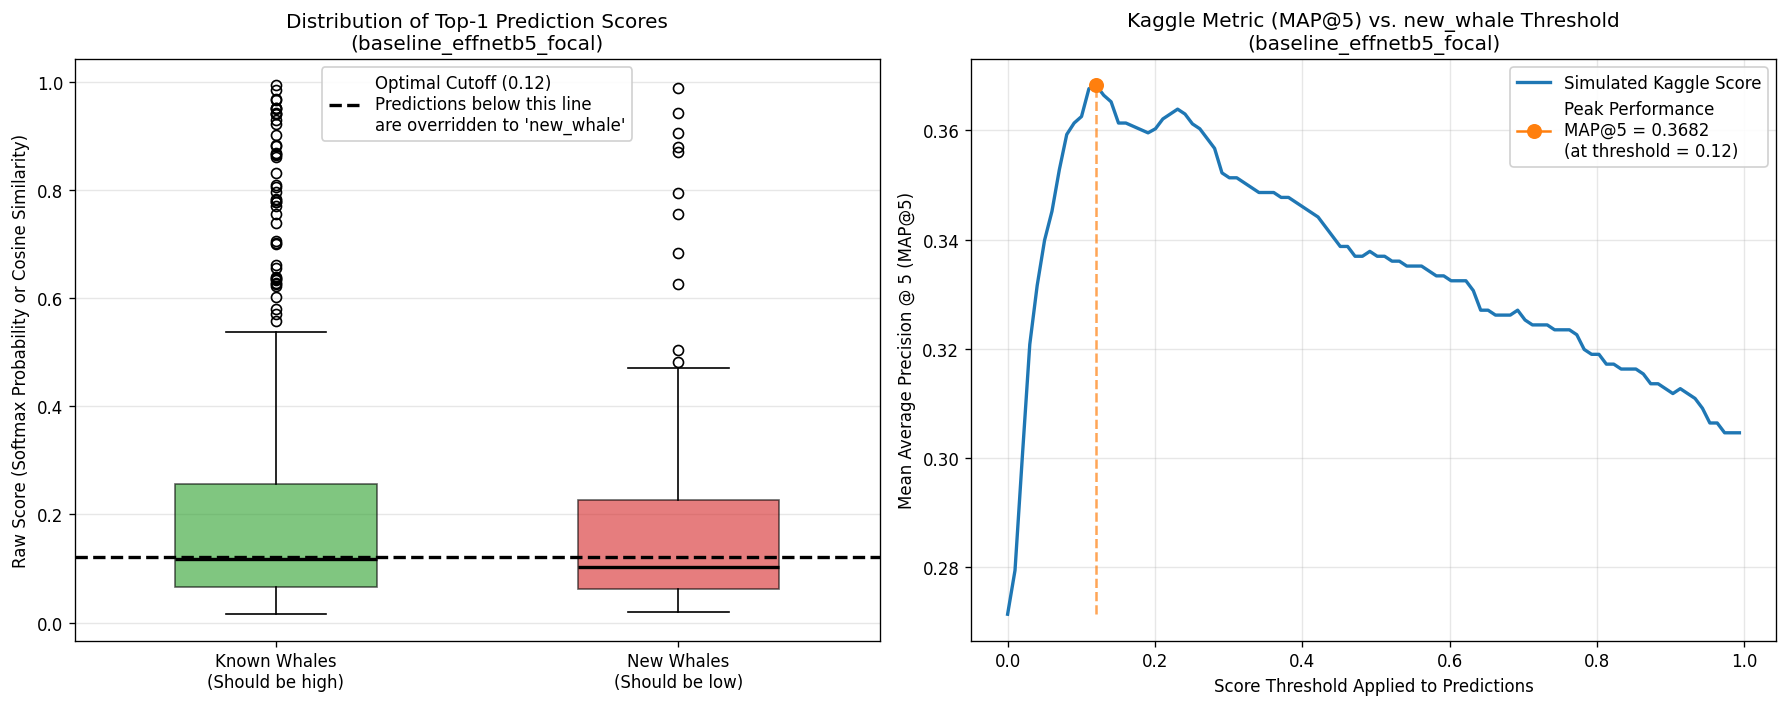


=== arcface ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/674 [00:16<?, ?it/s]

In [ ]:
results = {}

for name, info in experiments.items():
    print(f"\n=== {name} ===")
    config = ExperimentConfig.load(info["config"])
    config.include_new_whale_in_val = True

    data = prepare_data(config)

    if config.pk_sampling:
        train_loader, val_loader = build_metric_dataloaders(config, data)
    else:
        train_loader, val_loader = build_dataloaders(config, data)

    checkpoint = torch.load(info["checkpoint"], map_location=device, weights_only=False)
    extra = checkpoint.get("extra", {})
    num_classes = extra.get("num_classes", data["num_classes"])

    model = build_model(config, num_classes=num_classes, device=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    if config.head_type == "linear":
        scores, preds, labels = get_classifier_predictions(model, val_loader, device)
    else:
        scores, preds, labels = get_retrieval_predictions(model, train_loader, val_loader, device)

    base_metrics = evaluate_base_metrics(scores, preds, labels)
    thresholds, map_scores, best_t, best_map = sweep_thresholds(scores, preds, labels)

    results[name] = {
        "base_metrics": base_metrics,
        "best_threshold": best_t,
        "best_map5": best_map,
    }

    print("Base Metrics:", base_metrics)
    print(f"Optimal Threshold: {best_t:.3f} -> MAP@5: {best_map:.4f}")

    plot_evaluation(
        scores, labels, thresholds, map_scores,
        best_t, best_map,
        model_name=config.experiment_name or name
    )